1) nn.Embedding is just a Blank Spreadsheet (A Lookup Table).
When you write nn.Embedding(vocab_size=5000, embedding_dim=100) in PyTorch, you are essentially creating a blank Excel spreadsheet with 5,000 rows (one for each word) and 100 columns (the dimensions).
    - How it starts: By default, PyTorch fills this spreadsheet with completely random numbers. At Step 0, the word "King" and "Queen" have no meaningful relationship because their coordinates are random.
    - Its only job: Its only function is to take an integer (like Word ID #42) and return row #42 from the spreadsheet. It doesn't know anything about language; it is just a data structure.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import urllib.request
import re
from collections import Counter

# 1. Download Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

with open(filename, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# ====================
# 2. Tokenize to words
# ====================

# simple word tokenizer: lowercase, keep apostrophes, split on non-letters
tokens = re.findall(r"[A-Za-z']+", raw_text.lower())

# limit corpus for speed if you want (e.g., first 200k tokens)
max_tokens = 200_000
tokens = tokens[:max_tokens]

# ====================
# 3. Build vocab
# ====================

min_freq = 5  # drop super-rare words for smaller vocab
freq = Counter(tokens)
vocab = ["<pad>", "<unk>"] + [w for w, c in freq.items() if c >= min_freq]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

def encode(w):
    return word2idx.get(w, word2idx["<unk>"])

indices = [encode(w) for w in tokens]
vocab_size = len(vocab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Vocabulary Size: {vocab_size}")
print(f"Total Tokens:    {len(indices)}")

Using device: cuda
Vocabulary Size: 3263
Total Tokens:    200000


In [12]:
import requests, os, re, random
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# ====================
# 4. Build CBOW training pairs
# ====================

class CBOWDataset(Dataset):
    def __init__(self, indices, context_size=2):
        self.indices = indices
        self.context_size = context_size
        self.pairs = []
        N = len(indices)
        for i in range(context_size, N - context_size):
            context = indices[i - context_size:i] + indices[i + 1:i + 1 + context_size]
            target = indices[i]
            self.pairs.append((context, target))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        context, target = self.pairs[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)

context_size = 2
dataset = CBOWDataset(indices, context_size=context_size)

batch_size = 512
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

#### Word2Vec (including CBOW and Skip-Gram)

In [13]:
class Word2VecCBOW(nn.Module):
    def __init__(self, vocab_size, embid_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embid_dim)
        self.linear = nn.Linear(embid_dim, vocab_size)

    def forward(self, x):
        embedded = self.embeddings(x)
        context_embed = embedded.mean(dim=1)
        out = self.linear(context_embed)
        return out


In [14]:
class Word2VecSkipGram(nn.Module):
    def __init__(self, vocab_size, embid_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embid_dim)
        self.linear = nn.Linear(embid_dim, vocab_size)

    def forward(self, x):
        hidden = self.embeddings(x)
        out = self.linear(hidden)
        return out

In [20]:
embed_dim = 100
num_epoch = 5
#model = Word2VecCBOW(vocab_size, embed_dim).to(device)
model = Word2VecSkipGram(vocab_size, embed_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
for epoch in range(num_epoch):
    total_loss = 0
    for contexts, targets in dataloader:
        contexts, targets = contexts.to(device), targets.to(device)
        optimizer.zero_grad()

        ## CBOW
        # outputs = model(contexts)
        # loss = criterion(outputs, targets)

        ## Skip-gram (uncomment to train skip-gram instead)
        predictions = model(targets)
        loss = 0
        for i in range(contexts.shape[1]):
            target_context_word = contexts[:, i]
            loss += criterion(predictions, target_context_word)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epoch}, Loss: {total_loss/len(dataloader):.4f}")

Epoch 1/5, Loss: 28.5270
Epoch 2/5, Loss: 24.7849
Epoch 3/5, Loss: 23.9591
Epoch 4/5, Loss: 23.6148
Epoch 5/5, Loss: 23.4153


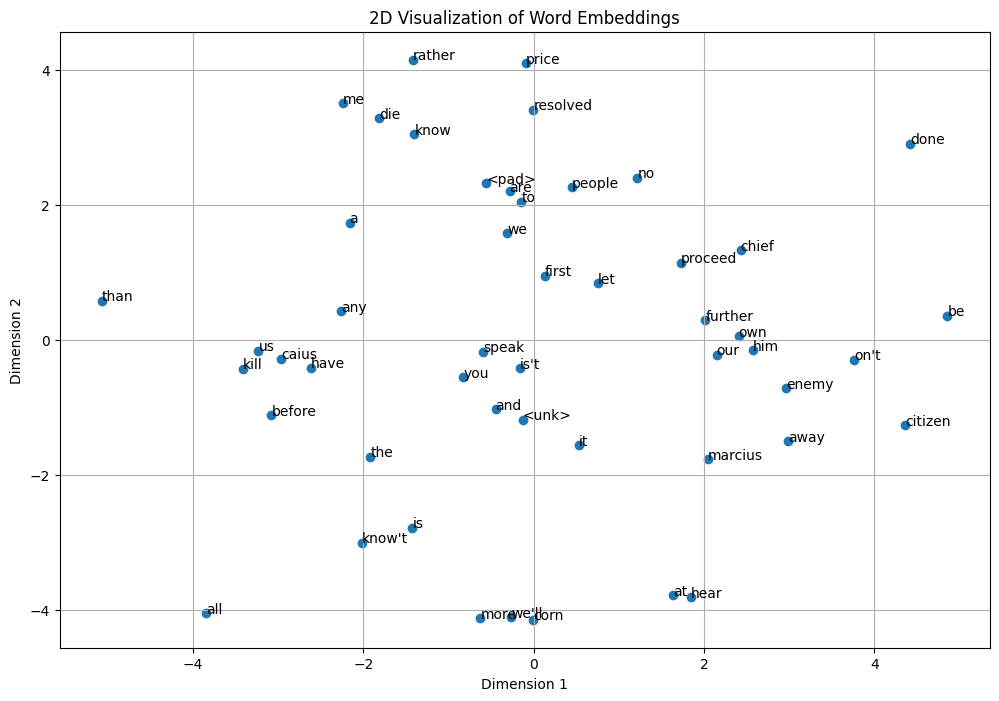

In [22]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# ----------------------------
# 2D Embedding Visualization
# ----------------------------
def plot_embeddings_2d(model, idx_to_word, method='pca', max_words=None):
    model.eval()

    # get embedding matrix from model
    embeddings = model.embeddings.weight.detach().cpu().numpy()
    words = [idx_to_word[i] for i in range(len(idx_to_word))]

    # optionally limit number of words for cleaner plot
    if max_words is not None:
        embeddings = embeddings[:max_words]
        words = words[:max_words]

    # reduce to 2D
    if method == 'pca':
        reducer = PCA(n_components=2)
        reduced = reducer.fit_transform(embeddings)
    else:
        raise ValueError("Currently only 'pca' is implemented")

    # plot
    plt.figure(figsize=(12, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

    plt.title("2D Visualization of Word Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.show()


# Example usage
plot_embeddings_2d(model, idx2word, method='pca', max_words=50)